In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.plot_styles import *

In [2]:
input_filename = 'Output/grid_353x161_0.csv'

In [3]:
def GetSolutionDict(input_filename):
    # Read the first three lines to extract grid sizes
    with open(input_filename, 'r') as f:
        ndim = int(f.readline().strip().split('=')[1])
        ni = int(f.readline().strip().split('=')[1])
        nj = int(f.readline().strip().split('=')[1])
        nk = int(f.readline().strip().split('=')[1])
    
    df = pd.read_csv(input_filename, skiprows=4)
    data_dict = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    return data_dict

    
data_dict = GetSolutionDict(input_filename)

In [4]:
data_dict.keys()

dict_keys(['x', 'y', 'z'])

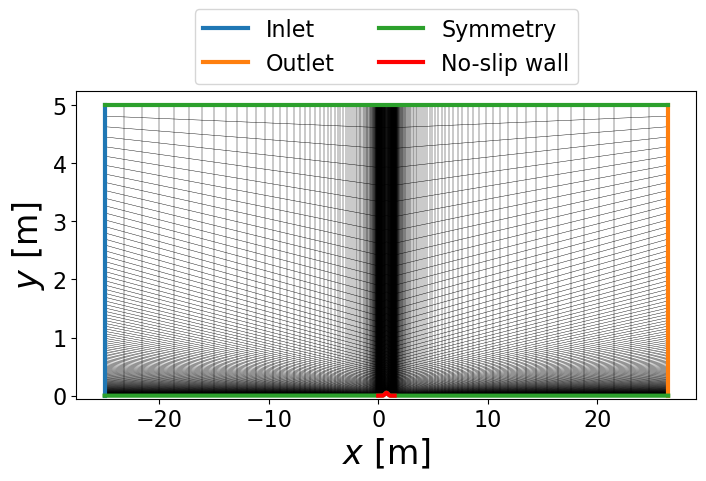

In [29]:
ni,nj,nk = data_dict['x'].shape
figsize = (8, 4)
lw = 0.3
plt.figure(figsize=figsize)
skip = 1
for i in range(0, ni, skip):
    plt.plot(data_dict['x'][i,:,0], data_dict['y'][i,:,0], 'k-', linewidth=lw)
for j in range(0, nj, skip):
    plt.plot(data_dict['x'][:,j,0], data_dict['y'][:,j,0], 'k-', linewidth=lw)

plt.plot(data_dict['x'][0,:,0], data_dict['y'][0,:,0], 'C0-', linewidth=3, label='Inlet')
plt.plot(data_dict['x'][-1,:,0], data_dict['y'][-1,:,0], 'C1-', linewidth=3, label='Outlet')
plt.plot(data_dict['x'][:,0,0], data_dict['y'][:,0,0], 'C2-', linewidth=3, label='Symmetry')
plt.plot(data_dict['x'][:,-1,0], data_dict['y'][:,-1,0], 'C2-', linewidth=3)
plt.plot(data_dict['x'][97:257,0,0], data_dict['y'][97:257,0,0], 'r-', linewidth=3, label='No-slip wall')

plt.legend(ncol=2, bbox_to_anchor=(0.5, 1.3), loc='upper center')
# plt.legend(ncol=2, fontsize=14)
plt.xlabel(r'$x$ [m]')
plt.ylabel(r'$y$ [m]')
# plt.xlim(right=0.7)
plt.ylim(bottom=-.05)
# plt.title('(%i x %i)' % (ni, nj))
# plt.gca().set_aspect('equal', adjustable='box')
plt.savefig('nasabump_grid.pdf', bbox_inches='tight')

In [28]:
ni,nj

(124, 64)